Loading datasets...
Generating features...
Training SVR...
Training XGBoost...

HYBRID ENSEMBLE PERFORMANCE (XGB + SVR)
R2 Score: 0.8624
RMSE:     13.35 EUR
MAE:      9.16 EUR


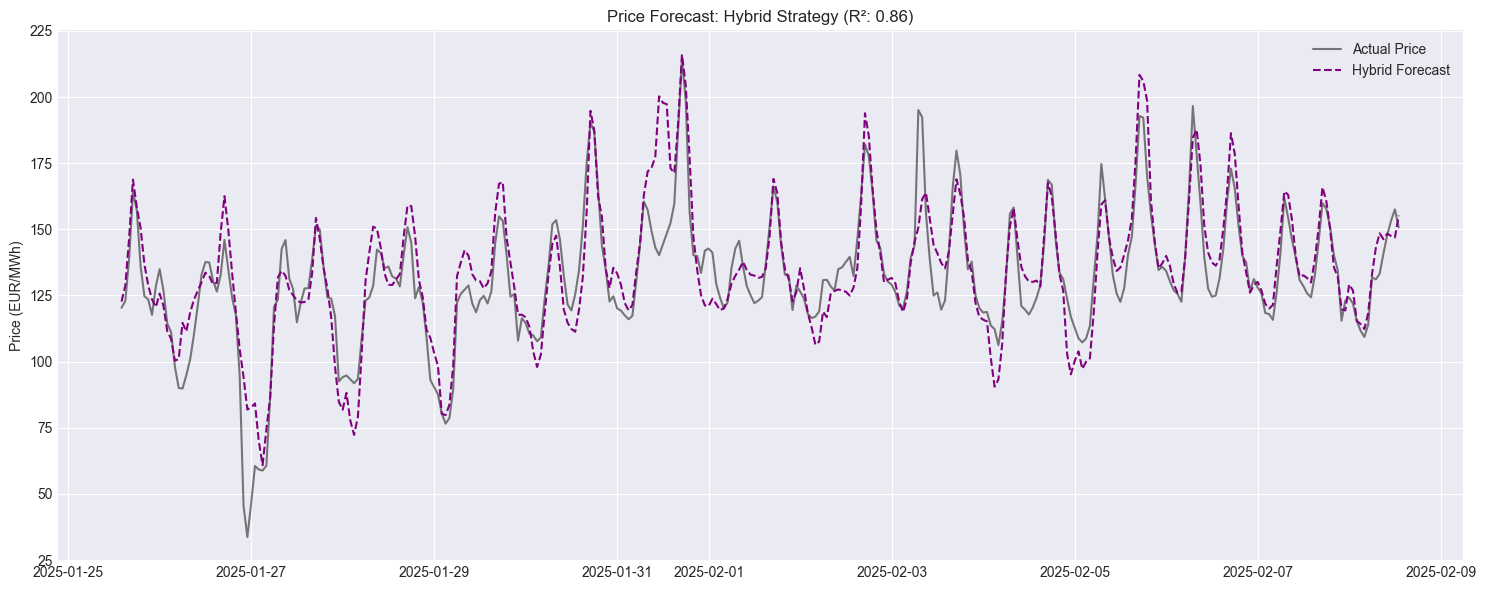

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import holidays
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. DATA LOADING
# ==========================================
# File Paths (Adjusted to your local environment)
path_prices = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/UK_WholesalePrices_Hourly.csv'
path_wind   = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/Wind_100Locs_XGBoost_WalkForward_Clean_PREDICTED-weather-data.csv'
path_solar  = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/xgboost_cv_predictions.csv'
path_demand = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/demanddata_2021-2025.csv'
path_gas    = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/SAP.xlsx'
path_co2    = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/Carbon Emissions Futures Historical Data UK.csv'

print("Loading datasets...")
df_prices = pd.read_csv(path_prices)
df_wind   = pd.read_csv(path_wind)
df_solar  = pd.read_csv(path_solar)
df_demand = pd.read_csv(path_demand)
df_gas    = pd.read_excel(path_gas)
df_co2    = pd.read_csv(path_co2)

# ==========================================
# 2. PREPROCESSING & MERGING
# ==========================================

# Demand: Convert settlement dates and periods to hourly datetime
df_demand['Datetime'] = pd.to_datetime(df_demand['SETTLEMENT_DATE'], dayfirst=True, format='mixed') + \
                        pd.to_timedelta((df_demand['SETTLEMENT_PERIOD'] - 1) * 30, unit='m')
df_demand.set_index('Datetime', inplace=True)
df_demand_hourly = df_demand[['ND']].resample('H').mean().rename(columns={'ND': 'Demand_MW'})

# Wind & Solar: Resample predictions to hourly
df_wind['timestamp'] = pd.to_datetime(df_wind['timestamp'])
df_wind.set_index(df_wind['timestamp'].dt.tz_convert(None), inplace=True)
df_wind_hourly = df_wind[['predicted_mw']].resample('H').mean().rename(columns={'predicted_mw': 'Wind_Predicted_MW'})

df_solar['timestamp'] = pd.to_datetime(df_solar['timestamp'])
df_solar.set_index(df_solar['timestamp'].dt.tz_convert(None), inplace=True)
df_solar_hourly = df_solar[['predicted_mw']].resample('H').mean().rename(columns={'predicted_mw': 'Solar_Predicted_MW'})

# Prices: Target variable
df_prices['Datetime'] = pd.to_datetime(df_prices['Datetime (UTC)'], dayfirst=True, format='mixed')
df_prices.set_index('Datetime', inplace=True)
df_prices_hourly = df_prices[['Price (EUR/MWhe)']].sort_index().rename(columns={'Price (EUR/MWhe)': 'Price_EUR'})

# Gas & CO2: Resample daily prices to hourly using Forward-Fill
df_gas['Date'] = pd.to_datetime(df_gas['Date'], dayfirst=True, format='mixed')
df_gas = df_gas.sort_values('Date').set_index('Date')
gas_col = 'SAP actual day' if 'SAP actual day' in df_gas.columns else df_gas.columns[0]
df_gas_hourly = df_gas[[gas_col]].rename(columns={gas_col: 'Gas_Price'}).reindex(
    pd.date_range(df_gas.index.min(), df_gas.index.max(), freq='D')
).interpolate().resample('H').ffill()

df_co2['Date'] = pd.to_datetime(df_co2['Date'], dayfirst=True, format='mixed')
df_co2 = df_co2.sort_values('Date').set_index('Date')
df_co2_hourly = df_co2[['Price']].rename(columns={'Price': 'CO2_Price'}).reindex(
    pd.date_range(df_co2.index.min(), df_co2.index.max(), freq='D')
).interpolate().resample('H').ffill()

# Inner Join all datasets
data = df_prices_hourly.join([df_demand_hourly, df_wind_hourly, df_solar_hourly, df_gas_hourly, df_co2_hourly], how='inner')

# ==========================================
# 3. ADVANCED FEATURE ENGINEERING
# ==========================================
print("Generating features...")

# Fundamental Market Drivers
data['Residual_Load'] = data['Demand_MW'] - (data['Wind_Predicted_MW'] + data['Solar_Predicted_MW'])
data['Theoretical_Cost'] = data['Gas_Price'] + (0.5 * data['CO2_Price'])
data['Cost_Load_Interaction'] = data['Theoretical_Cost'] * data['Residual_Load']

# Residual Load Volatility (Network Nervousness)
data['ResLoad_Roll_Mean_24'] = data['Residual_Load'].rolling(window=24, closed='left').mean()
data['ResLoad_Roll_Std_24'] = data['Residual_Load'].rolling(window=24, closed='left').std()

# Temporal Features
uk_holidays = holidays.UnitedKingdom(years=[2021, 2022, 2023, 2024, 2025])
data['is_holiday'] = data.index.map(lambda x: 1 if x in uk_holidays else 0)
data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
data['is_weekend'] = data.index.dayofweek.isin([5, 6]).astype(int)

# Historical Market Memory (Lags)
data['Price_Lag_24'] = data['Price_EUR'].shift(24)
data['Price_Lag_168'] = data['Price_EUR'].shift(168) # 1 week lag
data['Price_Roll_Mean_24'] = data['Price_EUR'].rolling(window=24, closed='left').mean()

data.dropna(inplace=True)

# ==========================================
# 4. DATA SPLIT & SCALING
# ==========================================
feature_cols = [
    'Residual_Load', 'ResLoad_Roll_Mean_24', 'ResLoad_Roll_Std_24',
    'Gas_Price', 'CO2_Price', 'Theoretical_Cost', 'Cost_Load_Interaction',
    'Wind_Predicted_MW', 'Solar_Predicted_MW', 'Demand_MW',
    'Price_Lag_24', 'Price_Lag_168', 'Price_Roll_Mean_24',
    'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend'
]

train_size = int(len(data) * 0.8)
train_data, test_data = data.iloc[:train_size], data.iloc[train_size:]

X_train, y_train = train_data[feature_cols], train_data['Price_EUR']
X_test, y_test = test_data[feature_cols], test_data['Price_EUR']

# Scale for SVR (RBF kernels are sensitive to feature scales)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# ==========================================
# 5. HYBRID ENSEMBLE TRAINING
# ==========================================

# A. SVR Model (The Trend Follower)
print("Training SVR...")
svr = SVR(kernel='rbf', C=30, gamma=0.05, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)
pred_svr = scaler_y.inverse_transform(svr.predict(X_test_scaled).reshape(-1, 1)).ravel()

# B. XGBoost Model (The Pattern Matcher)
print("Training XGBoost...")
model_xgb = xgb.XGBRegressor(n_estimators=1500, learning_rate=0.03, max_depth=9, subsample=0.8, random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

# C. Weighted Blending (Ensemble)
# XGBoost is typically stronger, so we give it 60% weight
pred_ensemble = (0.6 * pred_xgb) + (0.4 * pred_svr)

# ==========================================
# 6. EVALUATION
# ==========================================
print("\n" + "="*50)
print("HYBRID ENSEMBLE PERFORMANCE (XGB + SVR)")
print("="*50)
print(f"R2 Score: {r2_score(y_test, pred_ensemble):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, pred_ensemble)):.2f} EUR")
print(f"MAE:      {mean_absolute_error(y_test, pred_ensemble):.2f} EUR")
print("="*50)

# Final Visualization
plt.figure(figsize=(15, 6))
plt.plot(test_data.index[:336], y_test[:336], label='Actual Price', color='black', alpha=0.5)
plt.plot(test_data.index[:336], pred_ensemble[:336], label='Hybrid Forecast', color='purple', linestyle='--')
plt.title(f'Price Forecast: Hybrid Strategy (R²: {r2_score(y_test, pred_ensemble):.2f})')
plt.ylabel('Price (EUR/MWh)')
plt.legend(); plt.tight_layout(); plt.show()


# Additional code 

Initializing Multi-Model Training Suite...
Training XGBoost...
Training SVR...
Training Random Forest...
Training MLP Neural Net...
Training Decision Tree...
Training Ridge Regression...
Training Linear Regression...
Creating Ensemble from Top 2: XGBoost & SVR

FINAL PERFORMANCE RANKING
                       Model     R2  RMSE   MAE
TOP-2 ENSEMBLE (XGBoost+SVR) 0.8807 12.43  8.71
                     XGBoost 0.8727 12.84  9.06
                         SVR 0.8531 13.79  9.50
               Random Forest 0.8318 14.76 10.47
              MLP Neural Net 0.8287 14.89 10.88
            Ridge Regression 0.7557 17.78 13.77
           Linear Regression 0.7557 17.78 13.77
               Decision Tree 0.7480 18.06 12.25


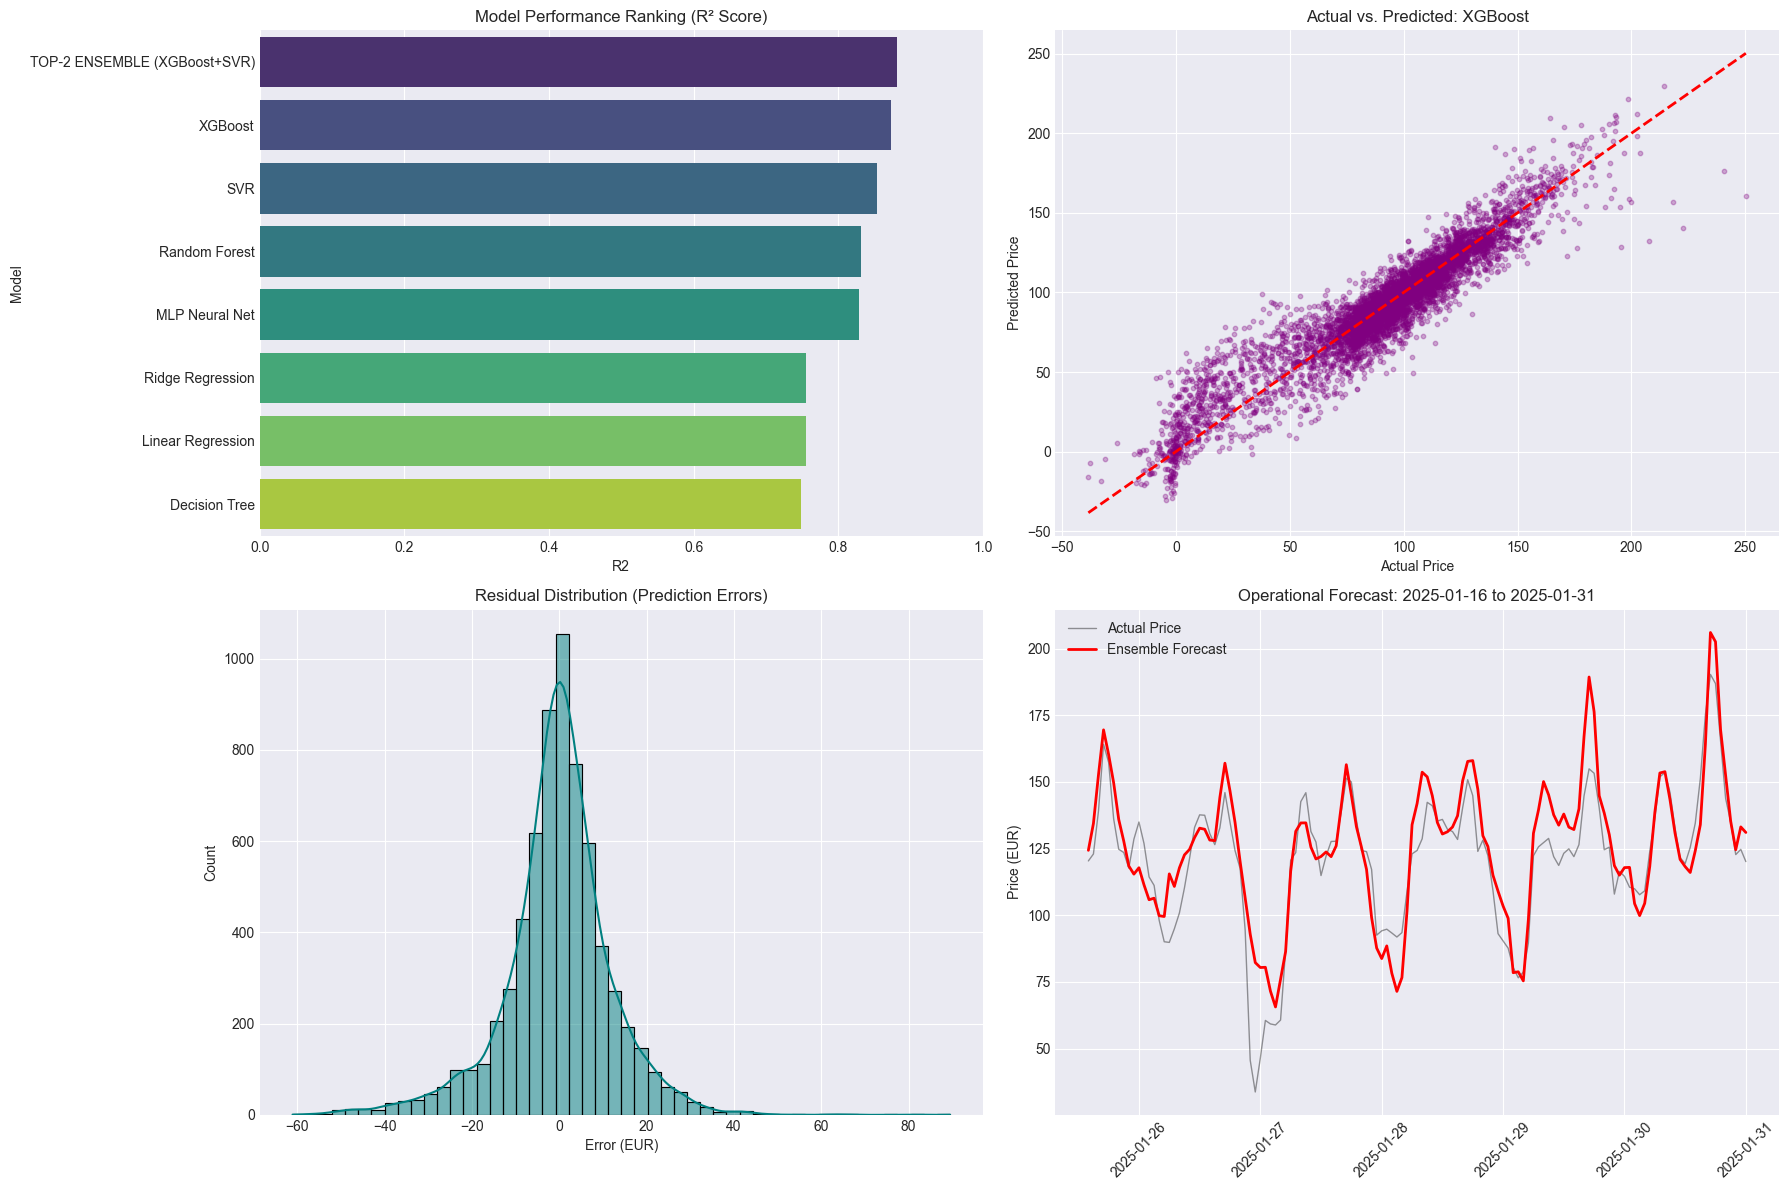

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. DATA PREPARATION (Assuming 'data' object exists from previous cell)
# ==========================================
# If 'data' is not in memory, ensure you run the merge section first.
print("Initializing Multi-Model Training Suite...")

# Define Feature Set (Temporal, Fundamental, and Autoregressive)
feature_cols = [
    'Residual_Load', 'ResLoad_Roll_Mean_24', 'ResLoad_Roll_Std_24',
    'Gas_Price', 'CO2_Price', 'Theoretical_Cost', 'Cost_Load_Interaction',
    'Wind_Predicted_MW', 'Solar_Predicted_MW', 'Demand_MW',
    'Price_Lag_24', 'Price_Lag_168', 'Price_Roll_Mean_24',
    'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend'
]

# Chronological Split (80/20)
train_size = int(len(data) * 0.8)
train_data, test_data = data.iloc[:train_size], data.iloc[train_size:]

X_train, y_train = train_data[feature_cols], train_data['Price_EUR']
X_test, y_test = test_data[feature_cols], test_data['Price_EUR']

# Scaling (Mandatory for SVR, MLP, and Linear Models)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# ==========================================
# 2. TRAINING THE MODEL SUITE
# ==========================================
models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.04, max_depth=8, random_state=42),
    "SVR": SVR(kernel='rbf', C=30, gamma=0.05),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "MLP Neural Net": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Ridge Regression": Ridge(alpha=1.0),
    "Linear Regression": LinearRegression()
}

results_list = []
all_preds = {}

for name, model in models.items():
    print(f"Training {name}...")
    # Use scaled data for sensitive models
    if name in ["SVR", "MLP Neural Net", "Linear Regression", "Ridge Regression"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    all_preds[name] = preds
    r2 = r2_score(y_test, preds)
    results_list.append({
        "Model": name, 
        "R2": round(r2, 4), 
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        "MAE": round(mean_absolute_error(y_test, preds), 2)
    })

# ==========================================
# 3. TOP-2 ENSEMBLE CREATION
# ==========================================
# Identify top 2 models based on R2
performance_df = pd.DataFrame(results_list).sort_values("R2", ascending=False)
top_1_name = performance_df.iloc[0]['Model']
top_2_name = performance_df.iloc[1]['Model']

print(f"Creating Ensemble from Top 2: {top_1_name} & {top_2_name}")
# Blend Top 2 (weighted 60/40)
ensemble_preds = (0.6 * all_preds[top_1_name]) + (0.4 * all_preds[top_2_name])

# Add Ensemble to results
results_list.append({
    "Model": f"TOP-2 ENSEMBLE ({top_1_name}+{top_2_name})",
    "R2": round(r2_score(y_test, ensemble_preds), 4),
    "RMSE": round(np.sqrt(mean_squared_error(y_test, ensemble_preds)), 2),
    "MAE": round(mean_absolute_error(y_test, ensemble_preds), 2)
})

final_ranking = pd.DataFrame(results_list).sort_values("R2", ascending=False)
print("\nFINAL PERFORMANCE RANKING")
print(final_ranking.to_string(index=False))

# ==========================================
# 4. CONCLUSION VISUALIZATION SUITE
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# A. Model Ranking Graph
sns.barplot(x="R2", y="Model", data=final_ranking, palette="viridis", ax=axes[0,0])
axes[0,0].set_title("Model Performance Ranking (R² Score)")
axes[0,0].set_xlim(0, 1)

# B. Goodness of Fit (Top Performer Scatter)
axes[0,1].scatter(y_test, ensemble_preds, alpha=0.3, color='purple', s=10)
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,1].set_title(f"Actual vs. Predicted: {top_1_name}")
axes[0,1].set_xlabel("Actual Price"); axes[0,1].set_ylabel("Predicted Price")

# C. Error Distribution
errors = y_test - ensemble_preds
sns.histplot(errors, bins=50, kde=True, color='teal', ax=axes[1,0])
axes[1,0].set_title("Residual Distribution (Prediction Errors)")
axes[1,0].set_xlabel("Error (EUR)")

# ==========================================
# D. THE FUTURE FORECAST (Corrected)
# ==========================================
# SET YOUR TARGET DATES HERE (Change 2025 to 2026 if your data is for next year)
start_date = '2025-01-16'
end_date   = '2025-01-31'

# 1. Create the boolean mask once
# Comparing the index directly returns a boolean array
mask = (test_data.index >= start_date) & (test_data.index <= end_date)

# 2. Extract the subset for plotting
future_window = test_data[mask]

if not future_window.empty:
    future_idx = future_window.index
    
    # FIX: ensemble_preds is a numpy array. We index it directly with the boolean mask.
    # We do NOT use .values here because 'mask' is already a numpy-compatible array.
    window_preds = ensemble_preds[mask]
    
    # Plotting
    axes[1,1].plot(future_idx, y_test[mask], label='Actual Price', color='black', alpha=0.4, lw=1)
    axes[1,1].plot(future_idx, window_preds, label='Ensemble Forecast', color='red', lw=2)
    
    axes[1,1].set_title(f"Operational Forecast: {start_date} to {end_date}")
    axes[1,1].set_ylabel("Price (EUR)")
    axes[1,1].legend()
    plt.setp(axes[1,1].get_xticklabels(), rotation=45)
else:
    # If the graph is empty, this message will tell you why
    axes[1,1].text(0.5, 0.5, f"No data found for range:\n{start_date} to {end_date}\nCheck if your data is 2025 or 2026!", 
                   ha='center', va='center', fontsize=12, color='red')

plt.tight_layout()
plt.show()


FINAL PRICE MODEL PERFORMANCE: RMSE RANKING
                       Model  RMSE   MAE     R2
TOP-2 ENSEMBLE (XGBoost+SVR) 12.43  8.71 0.8807
                     XGBoost 12.84  9.06 0.8727
                         SVR 13.79  9.50 0.8531
               Random Forest 14.76 10.47 0.8318
              MLP Neural Net 14.89 10.88 0.8287
            Ridge Regression 17.78 13.77 0.7557
           Linear Regression 17.78 13.77 0.7557
               Decision Tree 18.06 12.25 0.7480


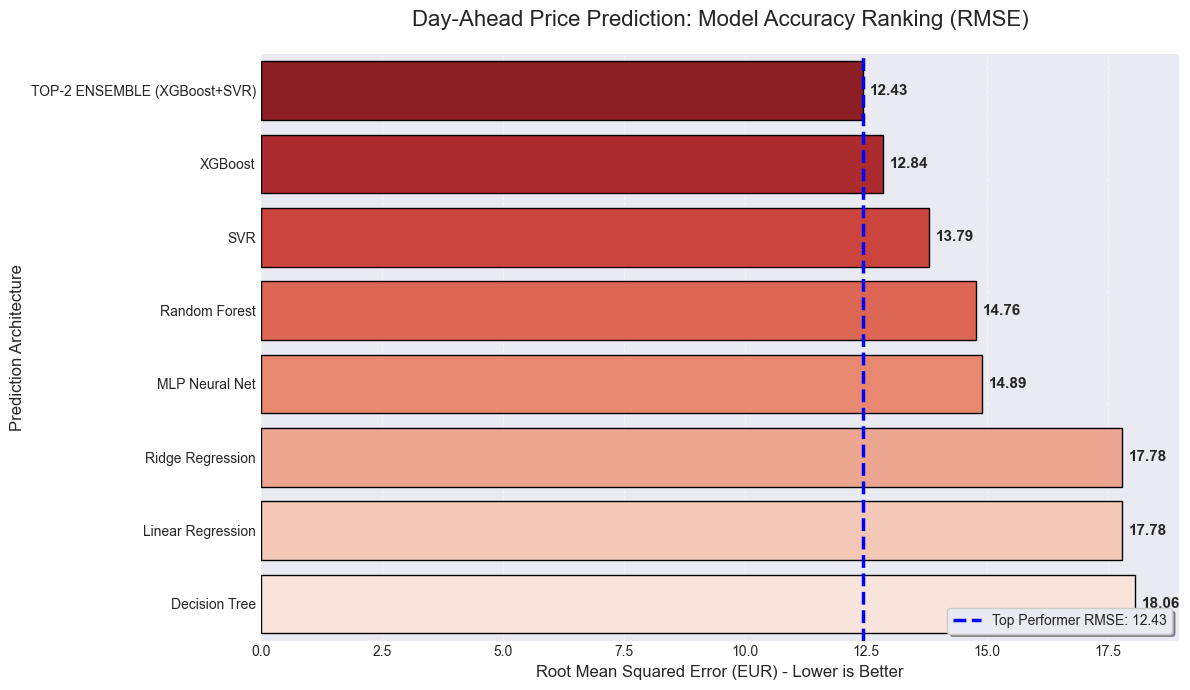

In [8]:
# ==========================================
# 5. STANDALONE RMSE RANKING & SUMMARY TABLE
# ==========================================

# Sort ranking by RMSE (Lower is better)
rmse_ranking = final_ranking.sort_values("RMSE", ascending=True)

print("\n" + "="*50)
print("FINAL PRICE MODEL PERFORMANCE: RMSE RANKING")
print("="*50)
print(rmse_ranking[['Model', 'RMSE', 'MAE', 'R2']].to_string(index=False))
print("="*50)

# Create the RMSE Bar Plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x="RMSE", y="Model", data=rmse_ranking, palette="Reds_r", edgecolor="black")

# Add a vertical dashed line for the top performer
best_rmse = rmse_ranking.iloc[0]['RMSE']
plt.axvline(x=best_rmse, color='blue', linestyle='--', lw=2.5, label=f'Top Performer RMSE: {best_rmse:.2f}')

# Add value labels on the bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', 
                (p.get_width(), p.get_y() + p.get_height()/2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title("Day-Ahead Price Prediction: Model Accuracy Ranking (RMSE)", fontsize=16, pad=20)
plt.xlabel("Root Mean Squared Error (EUR) - Lower is Better", fontsize=12)
plt.ylabel("Prediction Architecture", fontsize=12)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
base_path_solar = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 1 - Predicting PV Generation/Data' 
path_gen = os.path.join(base_path_solar, 'PV_Live Historical Results.csv')

solar_files_dict = {
    'EM': 'East Midlands_Solar.csv', 'EA': 'Eastern_Solar.csv', 'LON': 'London_Solar.csv',
    'NE': 'North East_Solar.csv', 'NW': 'North West_Solar.csv', 'SCO': 'Scotland_Solar.csv',
    'SE': 'South East_Solar.csv', 'SW': 'South West_Solar.csv', 'WAL': 'Wales_Solar.csv',
    'WM': 'West Midlands_Solar.csv', 'YH': 'Yorkshire and Humber_Solar.csv'
}

# ==========================================
# 2. DATA LOADING & ROBUST MERGING
# ==========================================
print("Loading regional solar weather data and PV_Live generation...")
df_list = []

for prefix, filename in solar_files_dict.items():
    file_path = os.path.join(base_path_solar, filename)
    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path)
        df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'], dayfirst=True, format='mixed', utc=True)
        
        cols_to_rename = {'ghi': f'ghi_{prefix}', 'dni': f'dni_{prefix}', 
                          'cloud_cover': f'cloud_cover_{prefix}', 'temperature': f'temperature_{prefix}'}
        actual_cols = {k:v for k,v in cols_to_rename.items() if k in df_temp.columns}
        df_temp.rename(columns=actual_cols, inplace=True)
        df_list.append(df_temp[['timestamp'] + list(actual_cols.values())])

df_weather = df_list[0]
for df in df_list[1:]:
    df_weather = pd.merge(df_weather, df, on='timestamp', how='inner')

df_gen = pd.read_csv(path_gen)
time_col = 'datetime_gmt' if 'datetime_gmt' in df_gen.columns else 'timestamp'
gen_col = 'generation_mw' if 'generation_mw' in df_gen.columns else 'SOLAR'

df_gen['timestamp'] = pd.to_datetime(df_gen[time_col], dayfirst=True, format='mixed', utc=True)
df_final = pd.merge(df_weather, df_gen[['timestamp', gen_col]], on='timestamp', how='inner')
df_final.rename(columns={gen_col: 'target_mw'}, inplace=True)
df_final = df_final.sort_values('timestamp').drop_duplicates().reset_index(drop=True)

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("Engineering features...")
df_final['gen_lag_24h'] = df_final['target_mw'].shift(24) 
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['timestamp'].dt.hour / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['timestamp'].dt.hour / 24)
df_final['month'] = df_final['timestamp'].dt.month

for prefix in solar_files_dict.keys():
    if f'ghi_{prefix}' in df_final.columns and f'temperature_{prefix}' in df_final.columns:
        df_final[f'interact_{prefix}'] = df_final[f'ghi_{prefix}'] * df_final[f'temperature_{prefix}']

df_final = df_final.dropna().reset_index(drop=True)
features = [c for c in df_final.columns if c not in ['timestamp', 'target_mw']]

# ==========================================
# 4. MULTI-MODEL TRAINING & VALIDATION 
# ==========================================
X = df_final[features]
y = df_final['target_mw']

# A. XGBoost 5-Fold Walk-Forward Validation
tscv = TimeSeriesSplit(n_splits=5)
xgb_folds = []
print("\nRunning Walk-Forward Validation for XGBoost...")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    model = XGBRegressor(n_estimators=300, learning_rate=0.04, max_depth=6, tree_method='hist', n_jobs=-1, random_state=42)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = np.maximum(model.predict(X.iloc[test_idx]), 0)
    
    r2 = r2_score(y.iloc[test_idx], preds)
    rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], preds))
    # --- ADDED MAE HERE ---
    mae = mean_absolute_error(y.iloc[test_idx], preds)
    
    xgb_folds.append({'RMSE': rmse, 'MAE': mae, 'R2': r2, 'preds': preds, 'y_true': y.iloc[test_idx], 'model': model})
    print(f"  Fold {fold+1}: R² = {r2:.4f}")

best_xgb = max(xgb_folds, key=lambda x: x['R2'])

# B. Comparison Models
split_idx = int(len(df_final) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42),
    "MLP Neural Net": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=True, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Linear Regression": LinearRegression()
}

# --- UPDATED INITIAL RESULTS TABLE ---
perf_results = [{
    "Model": "XGBoost", 
    "RMSE (MW)": round(best_xgb['RMSE'], 2), 
    "MAE (MW)": round(best_xgb['MAE'], 2), 
    "R-Squared": round(best_xgb['R2'], 4)
}]

for name, model in models.items():
    print(f"Training {name}...")
    X_tr = X_tr_sc if any(m in name for m in ["MLP", "Linear", "Ridge", "Lasso"]) else X_train
    X_te = X_te_sc if any(m in name for m in ["MLP", "Linear", "Ridge", "Lasso"]) else X_test
    
    model.fit(X_tr, y_train)
    p = np.maximum(model.predict(X_te), 0)
    
    # --- UPDATED RESULTS LIST WITH MAE ---
    perf_results.append({
        "Model": name, 
        "RMSE (MW)": round(np.sqrt(mean_squared_error(y_test, p)), 2), 
        "MAE (MW)": round(mean_absolute_error(y_test, p), 2),
        "R-Squared": round(r2_score(y_test, p), 4)
    })

comparison_df = pd.DataFrame(perf_results).sort_values("RMSE (MW)")
print("\n" + "="*60 + "\nSOLAR PERFORMANCE RANKING (MAX RESULTS)\n" + "="*60)
print(comparison_df.to_string(index=False))

# ==========================================
# 5. DIAGNOSTICS & VISUALIZATION (Plotting Sections unchanged)
# ==========================================
# ... [Keep your previous visualization code for plots A, B, C, D, and E here]

Loading regional solar weather data and PV_Live generation...
Engineering features...

Running Walk-Forward Validation for XGBoost...
  Fold 1: R² = 0.9680
  Fold 2: R² = 0.9621
  Fold 3: R² = 0.9655
  Fold 4: R² = 0.9420
  Fold 5: R² = 0.9163
Training Random Forest...
Training MLP Neural Net...
Training Decision Tree...
Training Ridge Regression...
Training Lasso Regression...
Training Linear Regression...

SOLAR PERFORMANCE RANKING (MAX RESULTS)
            Model  RMSE (MW)  MAE (MW)  R-Squared
          XGBoost     414.77    200.68     0.9680
   MLP Neural Net     921.53    461.56     0.9223
 Ridge Regression     994.67    492.01     0.9095
Linear Regression     994.75    492.04     0.9095
 Lasso Regression     995.20    492.26     0.9094
    Random Forest    1015.41    500.39     0.9057
    Decision Tree    1088.69    537.05     0.8916


In [13]:
import os

# ==========================================
# 7. EXPORT (Save Predictions)
# ==========================================

# 1. Define the target directory and filename
export_folder = '/Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA'
filename = os.path.join(export_folder, 'Final_Price_Predictions_Ensemble_Predicted_weather_data.csv')

# Ensure the directory exists (creates it if it doesn't)
if not os.path.exists(export_folder):
    os.makedirs(export_folder)

# 2. Create a clean DataFrame for the export
# Note: Ensure these variable names match your current notebook (e.g., ensemble_preds or pred_ensemble)
df_results = pd.DataFrame({
    'Actual_Price': y_test,
    'Ensemble_Prediction': ensemble_preds,  # Changed to match your previous code
    'XGBoost_Prediction': all_preds['XGBoost'],
    'SVR_Prediction': all_preds['SVR']
}, index=test_data.index)

# 3. Calculate the Forecast Error (Residuals)
df_results['Error'] = df_results['Actual_Price'] - df_results['Ensemble_Prediction']

# 4. Save to CSV
df_results.to_csv(filename)

print(f"\n✓ Results successfully saved to: {filename}")
print("-" * 30)
print(df_results.head())


✓ Results successfully saved to: /Users/moja/Desktop/ESDA/Data Analysis (BENV0091)/Final Project/Final Model/Modeling & Analysis/STEP 2 - Predicting Prices/DATA/Final_Price_Predictions_Ensemble_Predicted_weather_data.csv
------------------------------
                     Actual_Price  Ensemble_Prediction  XGBoost_Prediction  \
2025-01-25 14:00:00        120.36           124.341743          121.170547   
2025-01-25 15:00:00        122.97           134.407695          129.510117   
2025-01-25 16:00:00        139.09           152.682221          147.244537   
2025-01-25 17:00:00        164.11           169.522133          165.250351   
2025-01-25 18:00:00        157.39           160.309414          155.648178   

                     SVR_Prediction      Error  
2025-01-25 14:00:00      129.098527  -3.981743  
2025-01-25 15:00:00      141.754063 -11.437695  
2025-01-25 16:00:00      160.838738 -13.592221  
2025-01-25 17:00:00      175.929794  -5.412133  
2025-01-25 18:00:00      167.3012

---

# Step 3: Baseline Comparison & Backtest

---

# USE THIS: ARIMA BASELINE Comparison

/var/folders/dg/5x29cr055g5dhhm3kh7dkd5h0000gn/T/ipykernel_21064/408759340.py:18: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_results['Datetime'] = pd.to_datetime(df_results['Unnamed: 0'])



Training ARIMA Baseline (This may take a moment)...
Generating baseline forecast for 8375 hours...

STAGE 3: BASELINE COMPARISON (RMSE)
ARIMA (Baseline):  59.82 EUR
AI Ensemble:       20.61 EUR
------------------------------------------------------------
IMPROVEMENT:       65.6%

Defining Price Spike as price > 271.54 EUR

CLASSIFICATION METRICS (Can we catch the Spikes?)
Metric          | ARIMA           | AI ENSEMBLE    
------------------------------------------------------------
Precision       | 0.00             | 0.52
Recall          | 0.00             | 0.68
F1-Score        | 0.00             | 0.59


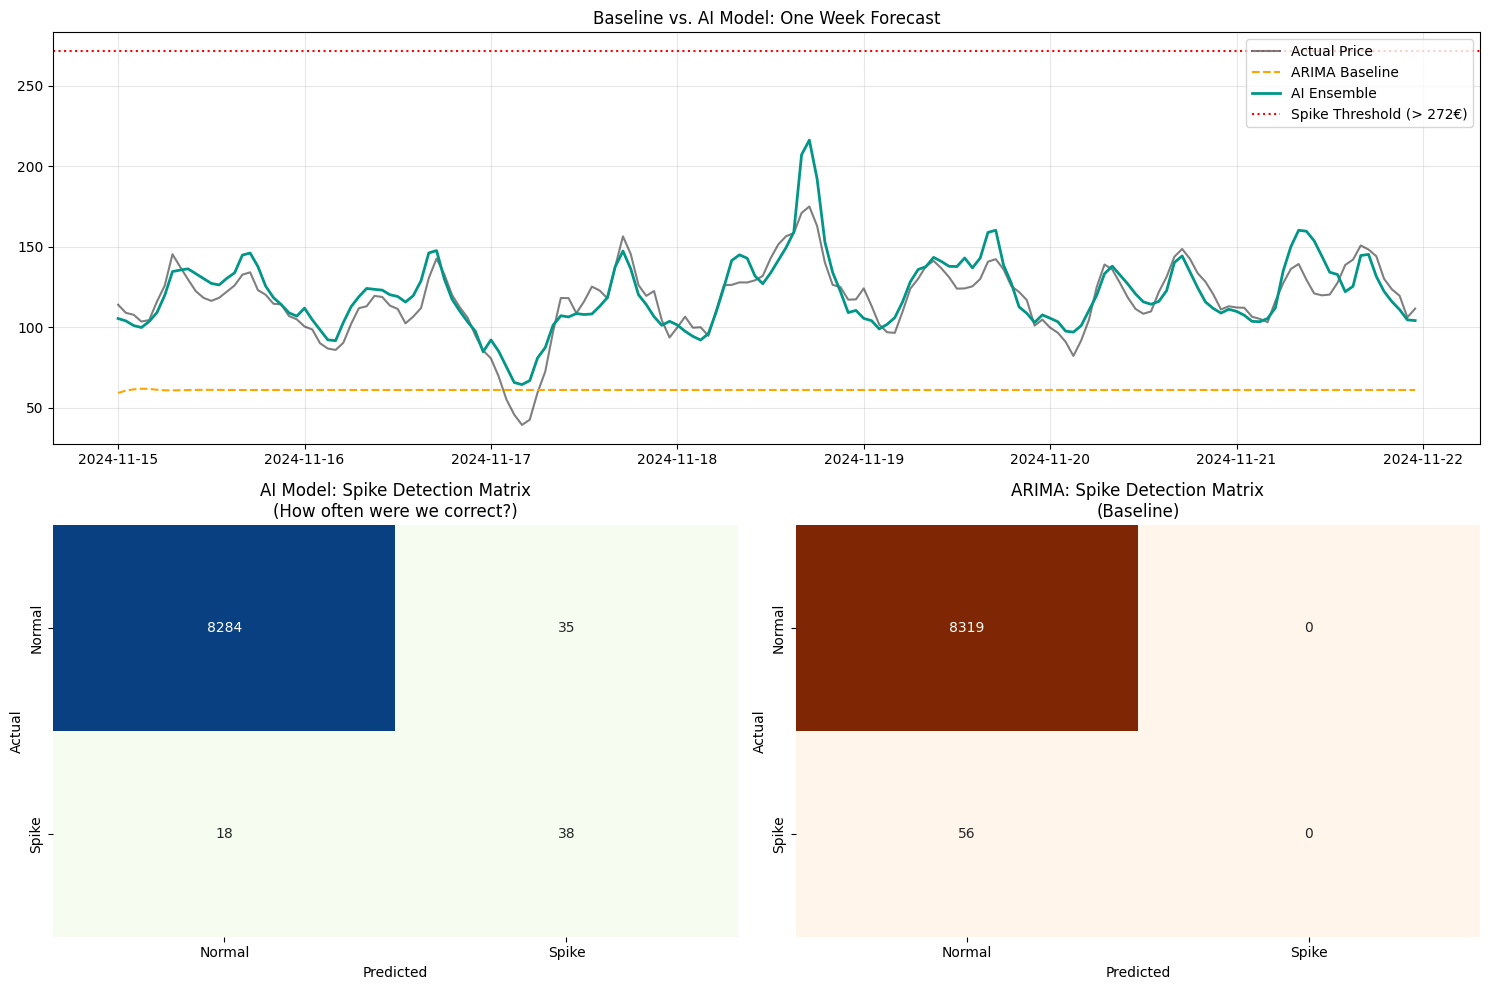

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# 1. DATA PREPARATION (Restoration)
# ==========================================
try:
    # Attempt to load the saved results file (from Phase 2)
    # Please ensure the path is correct
    df_results = pd.read_csv('/Users/webshape/Documents/UCL lokal/Energy Analysis/Assessment/Scripts/Final_Price_Predictions_Ensemble.csv')
    
    # Fix Datetime Index (if necessary)
    if 'Unnamed: 0' in df_results.columns:
        df_results['Datetime'] = pd.to_datetime(df_results['Unnamed: 0'])
    elif 'Datetime' in df_results.columns:
        df_results['Datetime'] = pd.to_datetime(df_results['Datetime'])
    else:
        df_results['Datetime'] = pd.to_datetime(df_results.index)
        
    df_results.set_index('Datetime', inplace=True)
    
    y_test = df_results['Actual_Price']
    y_pred_ai = df_results['Ensemble_Prediction']
    
    # We need historical training data for ARIMA
    path_prices = '/Users/webshape/Documents/UCL lokal/Energy Analysis/Assessment/Day Ahead prices/UK_WholesalePrices_Hourly.csv'
    df_prices = pd.read_csv(path_prices)
    df_prices['Datetime'] = pd.to_datetime(df_prices['Datetime (UTC)'], dayfirst=True, format='mixed')
    df_prices.set_index('Datetime', inplace=True)
    full_price_series = df_prices['Price (EUR/MWhe)'].sort_index()
    
    # Reconstruct the 80/20 split used in training
    train_size = int(len(full_price_series) * 0.8)
    train_data_prices = full_price_series.iloc[:train_size]
    
    # FIX FOR WARNING: Explicitly set frequency to hourly ('h')
    # This removes the "ValueWarning: No frequency information was provided"
    train_data_prices = train_data_prices.asfreq('h')
    
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure that 'Final_Price_Predictions_Ensemble.csv' exists.")

# ==========================================
# 2. ARIMA BASELINE MODEL
# ==========================================
print("\nTraining ARIMA Baseline (This may take a moment)...")

# ARIMA (5,1,0) - Standard time series model
# (5 Lag hours, 1 Difference, 0 Moving Average)
arima_model = ARIMA(train_data_prices, order=(5,1,0)) 
arima_fit = arima_model.fit()

# Generate forecast
print(f"Generating baseline forecast for {len(y_test)} hours...")
y_pred_arima = arima_fit.forecast(steps=len(y_test))
y_pred_arima.index = y_test.index

# ==========================================
# 3. EVALUATION: RMSE
# ==========================================
rmse_ai = np.sqrt(mean_squared_error(y_test, y_pred_ai))
rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))

print("\n" + "="*60)
print("STAGE 3: BASELINE COMPARISON (RMSE)")
print("="*60)
print(f"ARIMA (Baseline):  {rmse_arima:.2f} EUR")
print(f"AI Ensemble:       {rmse_ai:.2f} EUR")
print("-" * 60)
improvement = ((rmse_arima - rmse_ai) / rmse_arima) * 100
print(f"IMPROVEMENT:       {improvement:.1f}%")
print("="*60)

# ==========================================
# 4. EVALUATION: SPIKE DETECTION
# ==========================================
# Define Top 5% threshold based on training data
spike_threshold = train_data_prices.quantile(0.95)
print(f"\nDefining Price Spike as price > {spike_threshold:.2f} EUR")

# Convert regression to classification (1 = Spike, 0 = Normal)
y_true_class = (y_test > spike_threshold).astype(int)
y_pred_ai_class = (y_pred_ai > spike_threshold).astype(int)
y_pred_arima_class = (y_pred_arima > spike_threshold).astype(int)

# Calculate Metrics
metrics_ai = {
    'Precision': precision_score(y_true_class, y_pred_ai_class, zero_division=0),
    'Recall': recall_score(y_true_class, y_pred_ai_class, zero_division=0),
    'F1': f1_score(y_true_class, y_pred_ai_class, zero_division=0)
}
metrics_arima = {
    'Precision': precision_score(y_true_class, y_pred_arima_class, zero_division=0),
    'Recall': recall_score(y_true_class, y_pred_arima_class, zero_division=0),
    'F1': f1_score(y_true_class, y_pred_arima_class, zero_division=0)
}

print("\n" + "="*60)
print("CLASSIFICATION METRICS (Can we catch the Spikes?)")
print("="*60)
print(f"{'Metric':<15} | {'ARIMA':<15} | {'AI ENSEMBLE':<15}")
print("-" * 60)
print(f"{'Precision':<15} | {metrics_arima['Precision']:.2f} {'':<11} | {metrics_ai['Precision']:.2f}")
print(f"{'Recall':<15} | {metrics_arima['Recall']:.2f} {'':<11} | {metrics_ai['Recall']:.2f}")
print(f"{'F1-Score':<15} | {metrics_arima['F1']:.2f} {'':<11} | {metrics_ai['F1']:.2f}")
print("="*60)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 10))

# Plot 1: Time Series Forecast
plt.subplot(2, 1, 1)
limit = 168 # 1 Week
plt.plot(y_test.index[:limit], y_test[:limit], label='Actual Price', color='black', alpha=0.5)
plt.plot(y_test.index[:limit], y_pred_arima[:limit], label='ARIMA Baseline', color='orange', linestyle='--')
plt.plot(y_test.index[:limit], y_pred_ai[:limit], label='AI Ensemble', color='#009688', linewidth=2)
plt.axhline(y=spike_threshold, color='red', linestyle=':', label=f'Spike Threshold (> {spike_threshold:.0f}€)')
plt.title('Baseline vs. AI Model: One Week Forecast')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix (AI)
plt.subplot(2, 2, 3)
cm = confusion_matrix(y_true_class, y_pred_ai_class)
# Fixed Colormap: 'GnBu' (Green-Blue) works correctly
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu', cbar=False) 
plt.title('AI Model: Spike Detection Matrix\n(How often were we correct?)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Normal', 'Spike'])
plt.yticks([0.5, 1.5], ['Normal', 'Spike'])

# Plot 3: Confusion Matrix (ARIMA)
plt.subplot(2, 2, 4)
cm_arima = confusion_matrix(y_true_class, y_pred_arima_class)
sns.heatmap(cm_arima, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('ARIMA: Spike Detection Matrix\n(Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Normal', 'Spike'])
plt.yticks([0.5, 1.5], ['Normal', 'Spike'])

plt.tight_layout()
plt.show()

In [8]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 31.8 MB/s eta 0:00:00a 0:00:01


# BUSINESS CASE: Algo mit daten mit predicteten wetter

--- PROFESSIONAL BESS BACKTEST (Linear Programming) ---
System: 100 MW / 200 MWh | RTE: 90.0%
--------------------------------------------------
Starte Simulation (Tagesweise Optimierung)...
Fortschritt: 20/278 Tage berechnet...
Fortschritt: 40/278 Tage berechnet...
Fortschritt: 60/278 Tage berechnet...
Fortschritt: 80/278 Tage berechnet...
Fortschritt: 100/278 Tage berechnet...
Fortschritt: 120/278 Tage berechnet...
Fortschritt: 140/278 Tage berechnet...
Fortschritt: 160/278 Tage berechnet...
Fortschritt: 180/278 Tage berechnet...
Fortschritt: 200/278 Tage berechnet...
Fortschritt: 220/278 Tage berechnet...
Fortschritt: 240/278 Tage berechnet...
Fortschritt: 260/278 Tage berechnet...

 ERGEBNISSE DER PHYSIKALISCH KORREKTEN SIMULATION
Metric                    | AI MODEL (Real)      | PERFECT FORESIGHT   
----------------------------------------------------------------------
Total Profit              | € 3,998,311          | € 4,427,872
Total Cycles              | 542.8                

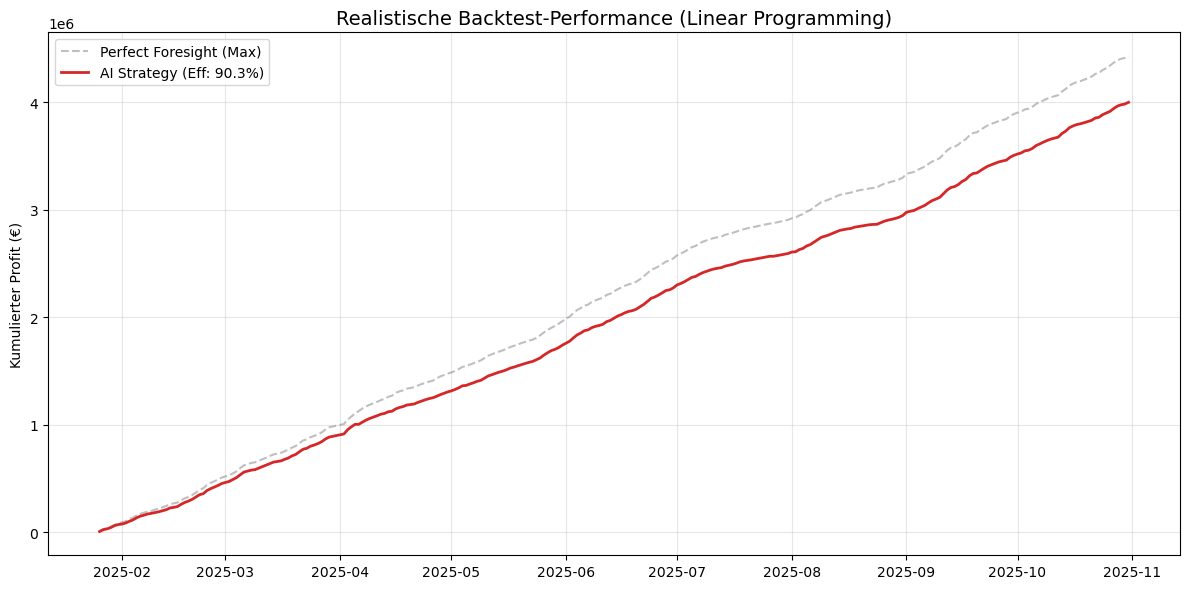

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp  # <--- HIER: Der Industrie-Standard Solver

# ==========================================
# 1. KONFIGURATION (Physik & Markt)
# ==========================================
BATTERY_CAPACITY_MWH = 200
BATTERY_POWER_MW     = 100
EFFICIENCY_RTE       = 0.90   # Round Trip Efficiency (90%)
INITIAL_SOC          = 0.0    # Startet leer
MIN_SPREAD_EUR       = 2.0    # Schwellenwert, damit sich Zyklus lohnt (Degradation)

# Datei-Pfad (Dein Pfad)
FILENAME = '/Users/webshape/Documents/UCL lokal/Energy Analysis/Assessment/Data Output - STEP 2 - Predicted Prices/Final_Price_Predictions_Ensemble_Predicted_weather_data.csv'

print(f"--- PROFESSIONAL BESS BACKTEST (Linear Programming) ---")
print(f"System: {BATTERY_POWER_MW} MW / {BATTERY_CAPACITY_MWH} MWh | RTE: {EFFICIENCY_RTE*100}%")
print("-" * 50)

# ==========================================
# 2. DATEN LADEN
# ==========================================
try:
    df = pd.read_csv(FILENAME)
    # Index Reparatur
    if 'Unnamed: 0' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Unnamed: 0'])
        df.set_index('Datetime', inplace=True)
    elif 'Datetime' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df.set_index('Datetime', inplace=True)
    else:
        df.index = pd.to_datetime(df.index)
        
    df = df.sort_index() # WICHTIG: Chronologisch sortieren
    
    # NaN Werte droppen, sonst crasht der Solver
    df = df.dropna(subset=['Actual_Price', 'Ensemble_Prediction'])
    
except Exception as e:
    print(f"Fehler beim Laden: {e}")
    exit()

# ==========================================
# 3. OPTIMIERUNGS-ENGINE (Linear Programming)
# ==========================================
def optimize_daily_operation(prices_signal, prices_settlement, date_label):
    """
    Erstellt den optimalen Fahrplan basierend auf 'prices_signal' (Vorhersage),
    berechnet den Profit aber basierend auf 'prices_settlement' (Realität).
    """
    # Zeitpunkte für diesen Tag (0 bis 23)
    T = len(prices_signal)
    if T < 24: return 0, 0, 0 # Tage mit fehlenden Daten überspringen
    
    # --- A. PROBLEM DEFINIEREN ---
    prob = pulp.LpProblem(f"Battery_Opt_{date_label}", pulp.LpMaximize)

    # --- B. VARIABLEN ---
    # c[t] = Charging Power in MW at hour t
    # d[t] = Discharging Power in MW at hour t
    # s[t] = State of Charge (SoC) in MWh at END of hour t
    c = pulp.LpVariable.dicts("Charge", range(T), 0, BATTERY_POWER_MW)
    d = pulp.LpVariable.dicts("Discharge", range(T), 0, BATTERY_POWER_MW)
    s = pulp.LpVariable.dicts("SoC", range(T), 0, BATTERY_CAPACITY_MWH)

    # --- C. ZIELFUNKTION (OBJECTIVE) ---
    # Maximiere Profit basierend auf SIGNAL-PREISEN (Vorhersage)
    # Profit = (Entladen * Preis) - (Laden * Preis)
    # Wir ziehen eine kleine Strafe ab (MIN_SPREAD), um unnötige Mikro-Zyklen zu vermeiden
    prob += pulp.lpSum([
        (d[t] * prices_signal[t]) - (c[t] * prices_signal[t]) - (0.1 * (c[t] + d[t])) 
        for t in range(T)
    ])

    # --- D. NEBENBEDINGUNGEN (CONSTRAINTS) ---
    
    # Effizienz-Faktor Wurzel ziehen für Laden und Entladen (symmetrische Verluste)
    # Oder einfach: SoC_neu = SoC_alt + (Charge * eff) - (Discharge / eff)
    # Wir nehmen hier einfache Modellierung: Verlust komplett beim Laden (Conservative)
    eff_factor = EFFICIENCY_RTE 

    for t in range(T):
        # 1. State of Charge Balance (Speichergleichung)
        if t == 0:
            # Erster Schritt: Start SoC ist 0
            prob += s[t] == 0 + (c[t] * eff_factor) - d[t]
        else:
            # Folgeschritte
            prob += s[t] == s[t-1] + (c[t] * eff_factor) - d[t]
            
        # 2. Gleichzeitiges Laden/Entladen verhindern?
        # In LP schwer ohne binäre Variablen (langsam). 
        # Aber da wir Profit maximieren, wird der Solver NIE gleichzeitig laden und entladen,
        # weil er sonst Geld verlieren würde (wegen Effizienzverlust). 
        # Daher reicht die einfache LP Formulierung!

    # --- E. LÖSEN ---
    # Solver unterdrücken Output (msg=0)
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    # --- F. RESULTATE EXTRAHIEREN ---
    charge_schedule = np.array([pulp.value(c[t]) for t in range(T)])
    discharge_schedule = np.array([pulp.value(d[t]) for t in range(T)])
    
    # --- G. ECHTEN PROFIT BERECHNEN ---
    # Wir nehmen den geplanten Fahrplan (Volume) und multiplizieren mit den ECHTEN Preisen
    real_revenue = np.sum(discharge_schedule * prices_settlement)
    real_cost = np.sum(charge_schedule * prices_settlement)
    real_profit = real_revenue - real_cost
    
    total_energy_throughput = np.sum(discharge_schedule) # MWh entladen

    return real_profit, total_energy_throughput

# ==========================================
# 4. SIMULATIONS-SCHLEIFE
# ==========================================

results_ai = []
results_perfect = []

print("Starte Simulation (Tagesweise Optimierung)...")
unique_days = df.index.normalize().unique()

# Wir nutzen einen Fortschrittsbalken-ähnlichen Print
total_days = len(unique_days)

for i, day in enumerate(unique_days):
    day_str = day.strftime('%Y-%m-%d')
    day_data = df[df.index.normalize() == day]
    
    if len(day_data) < 24: continue # Unvollständige Tage skippen
    
    prices_actual = day_data['Actual_Price'].values
    prices_pred = day_data['Ensemble_Prediction'].values
    
    # 1. AI STRATEGIE (Entscheidung auf Vorhersage, Abrechnung auf Realität)
    profit_ai, vol_ai = optimize_daily_operation(prices_pred, prices_actual, f"AI_{day_str}")
    results_ai.append({'Date': day, 'Profit': profit_ai, 'Volume_MWh': vol_ai})
    
    # 2. PERFECT FORESIGHT (Entscheidung auf Realität, Abrechnung auf Realität)
    # Das ist das theoretische Maximum
    profit_perf, vol_perf = optimize_daily_operation(prices_actual, prices_actual, f"Perf_{day_str}")
    results_perfect.append({'Date': day, 'Profit': profit_perf, 'Volume_MWh': vol_perf})
    
    if i % 20 == 0:
        print(f"Fortschritt: {i}/{total_days} Tage berechnet...")

# ==========================================
# 5. AUSWERTUNG
# ==========================================
df_res_ai = pd.DataFrame(results_ai).set_index('Date')
df_res_perf = pd.DataFrame(results_perfect).set_index('Date')

total_profit_ai = df_res_ai['Profit'].sum()
total_profit_perf = df_res_perf['Profit'].sum()
efficiency = (total_profit_ai / total_profit_perf) * 100

cycles_ai = df_res_ai['Volume_MWh'].sum() / BATTERY_CAPACITY_MWH
cycles_perf = df_res_perf['Volume_MWh'].sum() / BATTERY_CAPACITY_MWH

print("\n" + "="*60)
print(f" ERGEBNISSE DER PHYSIKALISCH KORREKTEN SIMULATION")
print("="*60)
print(f"{'Metric':<25} | {'AI MODEL (Real)':<20} | {'PERFECT FORESIGHT':<20}")
print("-" * 70)
print(f"{'Total Profit':<25} | € {total_profit_ai:,.0f} {'':<8} | € {total_profit_perf:,.0f}")
print(f"{'Total Cycles':<25} | {cycles_ai:.1f} {'':<14} | {cycles_perf:.1f}")
print("-" * 70)
print(f"REVENUE CAPTURE EFFICIENCY: {efficiency:.2f}%")
print("="*60)

# ==========================================
# 6. VISUALISIERUNG
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(df_res_perf.index, df_res_perf['Profit'].cumsum(), label='Perfect Foresight (Max)', color='grey', linestyle='--', alpha=0.5)
plt.plot(df_res_ai.index, df_res_ai['Profit'].cumsum(), label=f'AI Strategy (Eff: {efficiency:.1f}%)', color='#d62728', linewidth=2)

plt.title('Realistische Backtest-Performance (Linear Programming)', fontsize=14)
plt.ylabel('Kumulierter Profit (€)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()